Olá, André

Meu nome é Ramon. Ao ao longo do texto farei algumas observações sobre melhorias no código. Nas partes em que não houver comentários, está tudo certo, ok? Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser consertado, caso contrário seu projeto **não** será aceito.
</div>

Você pode me responder usando isso:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

###

<div class="alert alert-block alert-success">
<b>Comentário Geral do Revisor</b> <a class="tocSkip"></a>

Obrigado por enviar seu projeto. 
    
Parabéns, você fez um bom trabalho.

Como pontos fortes do projeto, destaco:
- Código simples e eficiente (sem loop desnecessário)
- Uso adequado dos recursos da lição
- Bons gráficos   


Gabaritou o projeto (o que é raro de acontecer neste projeto deixei apenas 2 dois códigos ilustrando outras formas de visualização) Parabéns pela dedicação. Desejo sucesso na jornada.


</div>



# Product and Marketing Analytics: Otimização de Aquisição de Clientes

## Objetivo da Análise

Este projeto analisa dados de comportamento de usuários, vendas e custos de marketing com o objetivo de avaliar a eficiência dos canais de aquisição.

A análise inclui métricas de produto e marketing como **DAU, retenção, conversão, LTV, CAC e ROMI**, permitindo identificar quais canais de marketing geram maior valor para o negócio e orientar decisões de investimento.


## Importação e Exploração de Dados


In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

## Inspeção Inicial

In [140]:
print(visits.info())
print(orders.info())
print(costs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     -------------- 

In [141]:
print("--- Amostra: Visits ---")
display(visits.head())

print("\n--- Amostra: Orders ---")
display(orders.head())

print("\n--- Amostra: Costs ---")
display(costs.head())

--- Amostra: Visits ---


,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168



--- Amostra: Orders ---


,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450



--- Amostra: Costs ---


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [142]:
print("--- Estatísticas: Visits ---")
display(visits.describe())

print("\n--- Estatísticas: Orders ---")
display(orders.describe())

print("\n--- Estatísticas: Costs ---")
display(costs.describe())

--- Estatísticas: Visits ---


,Source Id,Uid
count,359400.000000,3.594000e+05
mean,3.750515,9.202557e+18
std,1.917116,5.298433e+18
min,1.000000,1.186350e+13
25%,3.000000,4.613407e+18
50%,4.000000,9.227413e+18
75%,5.000000,1.372824e+19
max,10.000000,1.844668e+19



--- Estatísticas: Orders ---


,Revenue,Uid
count,50415.000000,5.041500e+04
mean,4.999647,9.098161e+18
std,21.818359,5.285742e+18
min,0.000000,3.135781e+14
25%,1.220000,4.533567e+18
50%,2.500000,9.102274e+18
75%,4.890000,1.368290e+19
max,2633.280000,1.844617e+19



--- Estatísticas: Costs ---


,source_id,costs
count,2542.000000,2542.000000
mean,4.857199,129.477427
std,3.181581,156.296628
min,1.000000,0.540000
25%,2.000000,21.945000
50%,4.000000,77.295000
75%,9.000000,170.065000
max,10.000000,1788.280000


In [143]:
# Valores Nulos 
print("--- Valores Nulos ---")
print(f"Visits:\n{visits.isna().sum()}\n")
print(f"Orders:\n{orders.isna().sum()}\n")
print(f"Costs:\n{costs.isna().sum()}\n")

# Duplicados Explícitos 
print("--- Duplicados Totais ---")
print(f"Visits: {visits.duplicated().sum()}")
print(f"Orders: {orders.duplicated().sum()}")
print(f"Costs: {costs.duplicated().sum()}")

--- Valores Nulos ---
Visits:
Device       0
End Ts       0
Source Id    0
Start Ts     0
Uid          0
dtype: int64

Orders:
Buy Ts     0
Revenue    0
Uid        0
dtype: int64

Costs:
source_id    0
dt           0
costs        0
dtype: int64

--- Duplicados Totais ---
Visits: 0
Orders: 0
Costs: 0


## Conversão

In [144]:
# 1. Conversão para Datetime 
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

# 2. Otimização de Memória 
visits['Device'] = visits['Device'].astype('category')

# 3. Verificação do Sucesso da Operação
print("--- Novos Tipos de Dados ---")
print(f"Visits:\n{visits.dtypes}\n")
print(f"Orders:\n{orders.dtypes}\n")
print(f"Costs:\n{costs.dtypes}")

--- Novos Tipos de Dados ---
Visits:
Device             category
End Ts       datetime64[ns]
Source Id             int64
Start Ts     datetime64[ns]
Uid                  uint64
dtype: object

Orders:
Buy Ts     datetime64[ns]
Revenue           float64
Uid                uint64
dtype: object

Costs:
source_id             int64
dt           datetime64[ns]
costs               float64
dtype: object


## Calculo de métricas:

In [145]:
# Preparação das colunas de tempo
visits['session_year']  = visits['Start Ts'].dt.year
visits['session_month'] = visits['Start Ts'].dt.month
visits['session_week']  = visits['Start Ts'].dt.isocalendar().week
visits['session_date']  = visits['Start Ts'].dt.date

# Cálculo das métricas
dau = visits.groupby('session_date').agg({'Uid': 'nunique'}).mean()
wau = visits.groupby(['session_year', 'session_week']).agg({'Uid': 'nunique'}).mean()
mau = visits.groupby(['session_year', 'session_month']).agg({'Uid': 'nunique'}).mean()

print(f"DAU (Média de usuários por dia): {int(dau)}")
print(f"WAU (Média de usuários por semana): {int(wau)}")
print(f"MAU (Média de usuários por mês): {int(mau)}")

DAU (Média de usuários por dia): 907
WAU (Média de usuários por semana): 5716
MAU (Média de usuários por mês): 23228


In [146]:
sessions_per_day = visits.groupby('session_date').agg({'Uid': ['count', 'nunique']})
sessions_per_day.columns = ['n_sessions', 'n_users']
sessions_per_day['sessions_per_user'] = sessions_per_day['n_sessions'] / sessions_per_day['n_users']

print(f"Média de sessões por dia: {sessions_per_day['n_sessions'].mean():.2f}")

Média de sessões por dia: 987.36


In [147]:
visits['session_duration_sec'] = (visits['End Ts'] - visits['Start Ts']).dt.seconds

# Duração média e a mais frequente (Moda)
asl_mean = visits['session_duration_sec'].mean()
asl_mode = visits['session_duration_sec'].mode()

print(f"Duração média: {asl_mean:.2f} segundos")
print(f"Duração mais frequente (Moda): {asl_mode[0]} segundos")

Duração média: 643.51 segundos
Duração mais frequente (Moda): 60 segundos


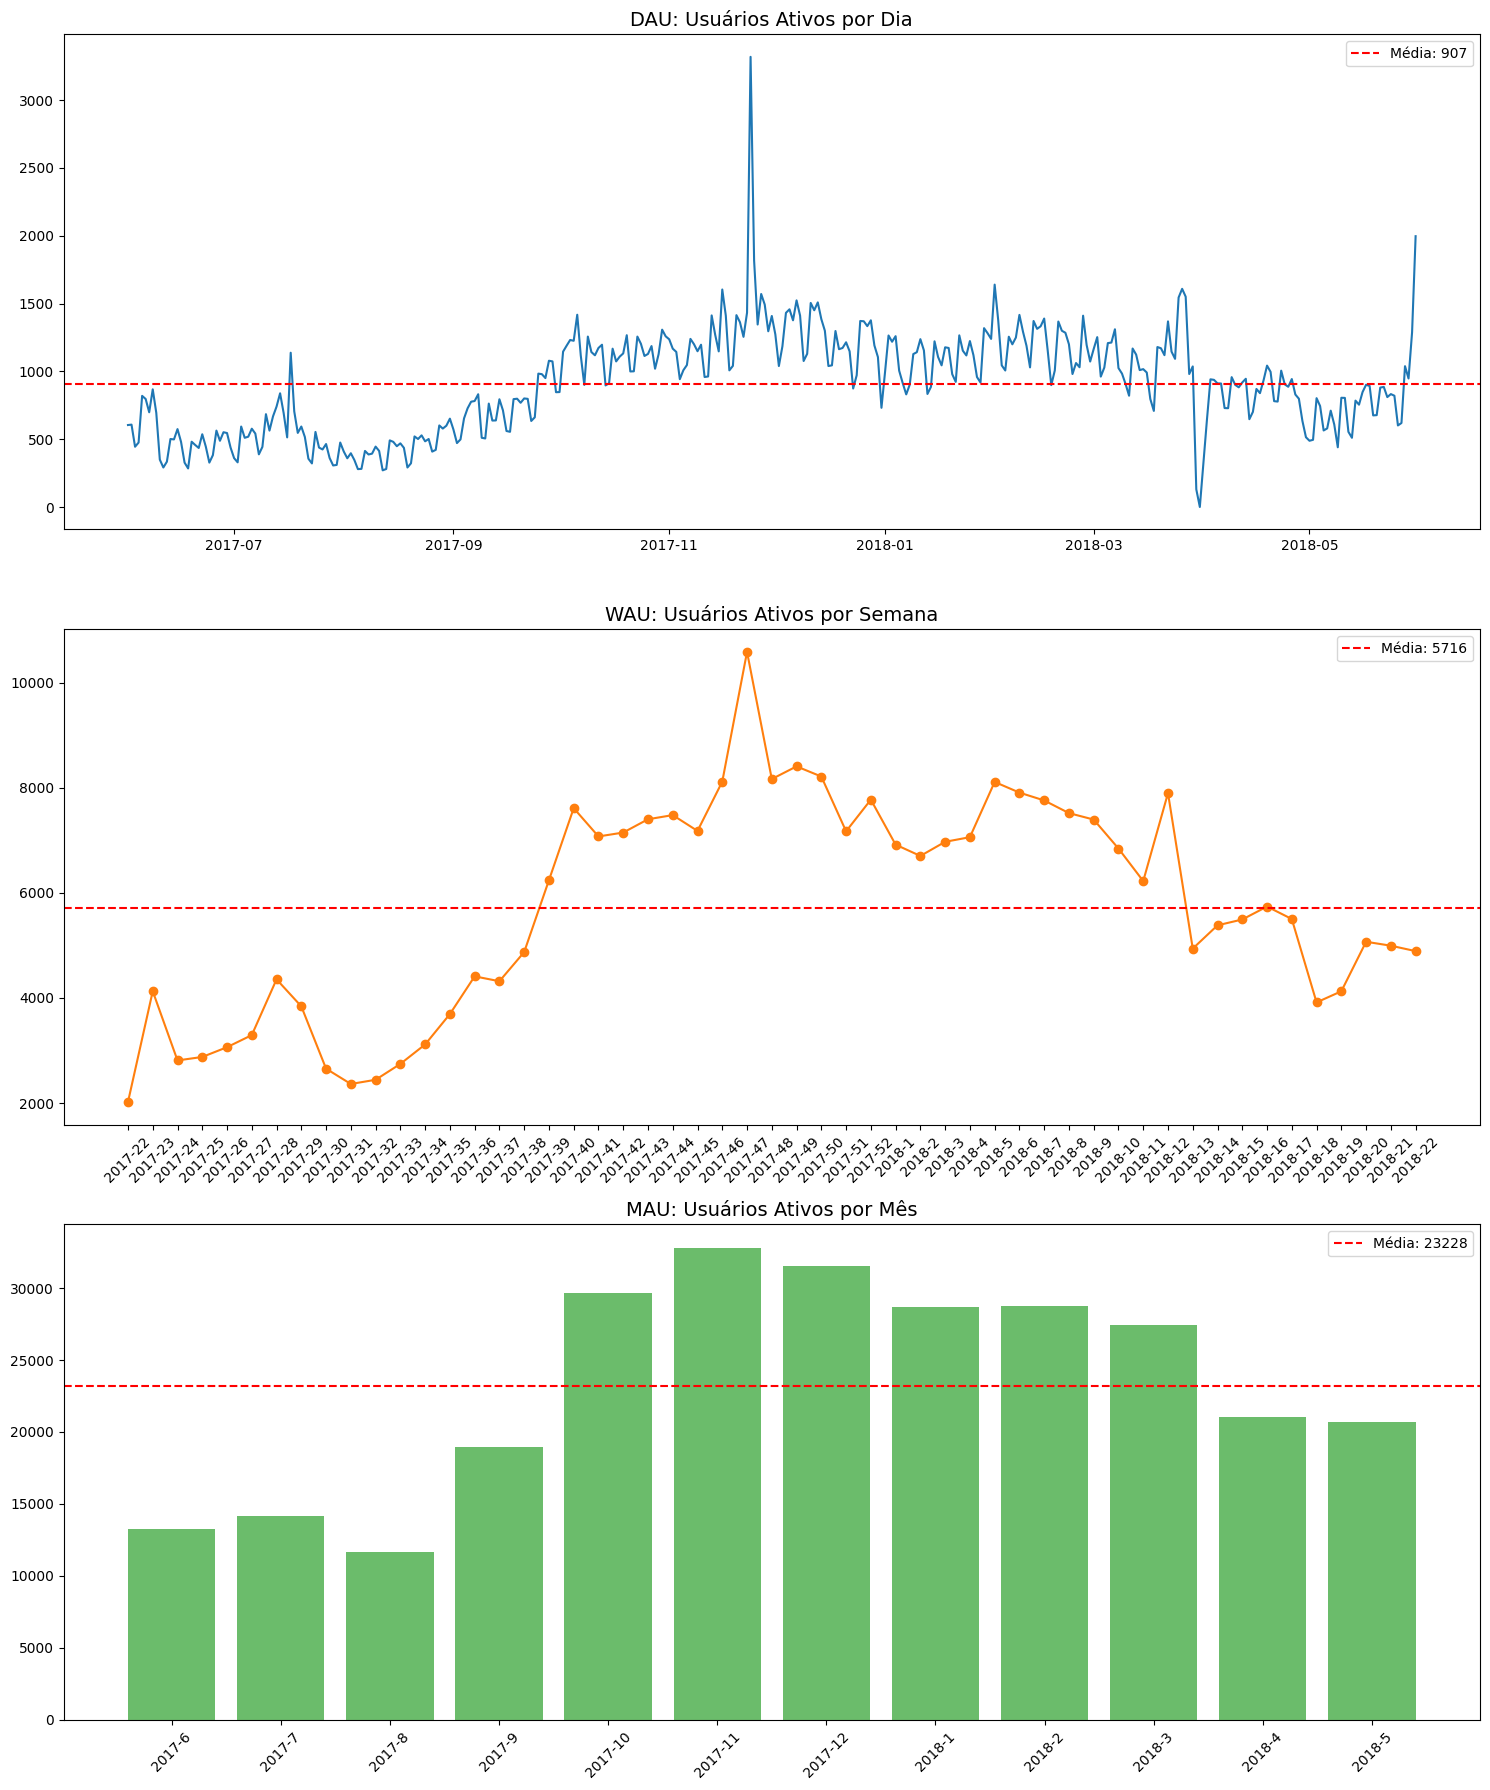

In [148]:
# 1. Agrupamento dos dados
dau_timeline = visits.groupby('session_date').agg({'Uid': 'nunique'})
wau_timeline = visits.groupby(['session_year', 'session_week']).agg({'Uid': 'nunique'}).reset_index()
mau_timeline = visits.groupby(['session_year', 'session_month']).agg({'Uid': 'nunique'}).reset_index()

# Criando identificadores legíveis para os eixos X de WAU e MAU
wau_timeline['week_id'] = wau_timeline['session_year'].astype(str) + "-" + wau_timeline['session_week'].astype(str)
mau_timeline['month_id'] = mau_timeline['session_year'].astype(str) + "-" + mau_timeline['session_month'].astype(str)

# 2. Configuração da Figura
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# Gráfico DAU
axes[0].plot(dau_timeline.index, dau_timeline['Uid'], color='tab:blue')
axes[0].set_title('DAU: Usuários Ativos por Dia', fontsize=14)
axes[0].axhline(y=907, color='red', linestyle='--', label='Média: 907')
axes[0].legend()

# Gráfico WAU
axes[1].plot(wau_timeline['week_id'], wau_timeline['Uid'], color='tab:orange', marker='o')
axes[1].set_title('WAU: Usuários Ativos por Semana', fontsize=14)
axes[1].axhline(y=5716, color='red', linestyle='--', label='Média: 5716')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Gráfico MAU
axes[2].bar(mau_timeline['month_id'], mau_timeline['Uid'], color='tab:green', alpha=0.7)
axes[2].set_title('MAU: Usuários Ativos por Mês', fontsize=14)
axes[2].axhline(y=23228, color='red', linestyle='--', label='Média: 23228')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

Duração Média: 643.51 segundos
Duração Mediana: 300.00 segundos
Duração Mais Frequente (Moda): 60 segundos


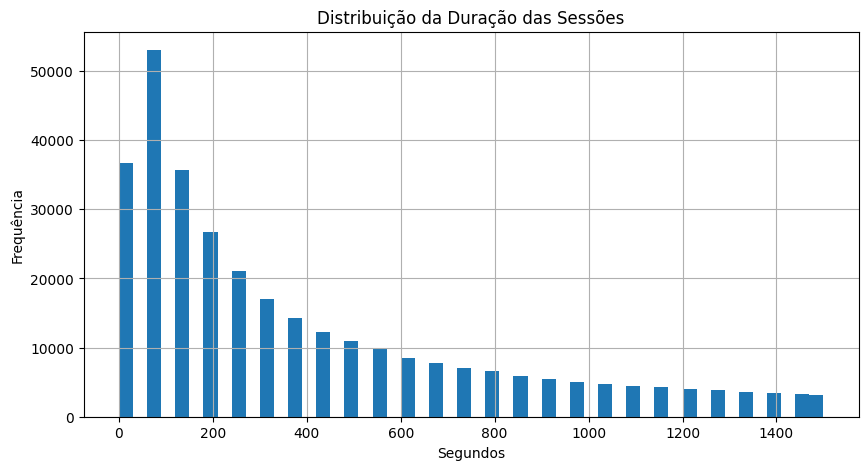

In [149]:
# Cálculo da duração em segundos
visits['session_duration_sec'] = (visits['End Ts'] - visits['Start Ts']).dt.seconds

# Estatísticas de Auditoria
asl_mean = visits['session_duration_sec'].mean()
asl_median = visits['session_duration_sec'].median()
asl_mode = visits['session_duration_sec'].mode()[0]

print(f"Duração Média: {asl_mean:.2f} segundos")
print(f"Duração Mediana: {asl_median:.2f} segundos")
print(f"Duração Mais Frequente (Moda): {asl_mode} segundos")

# Gráfico de Distribuição para o Relatório
import matplotlib.pyplot as plt
visits['session_duration_sec'].hist(bins=50, range=(0, 1500), figsize=(10, 5))
plt.title('Distribuição da Duração das Sessões')
plt.xlabel('Segundos')
plt.ylabel('Frequência')
plt.show()

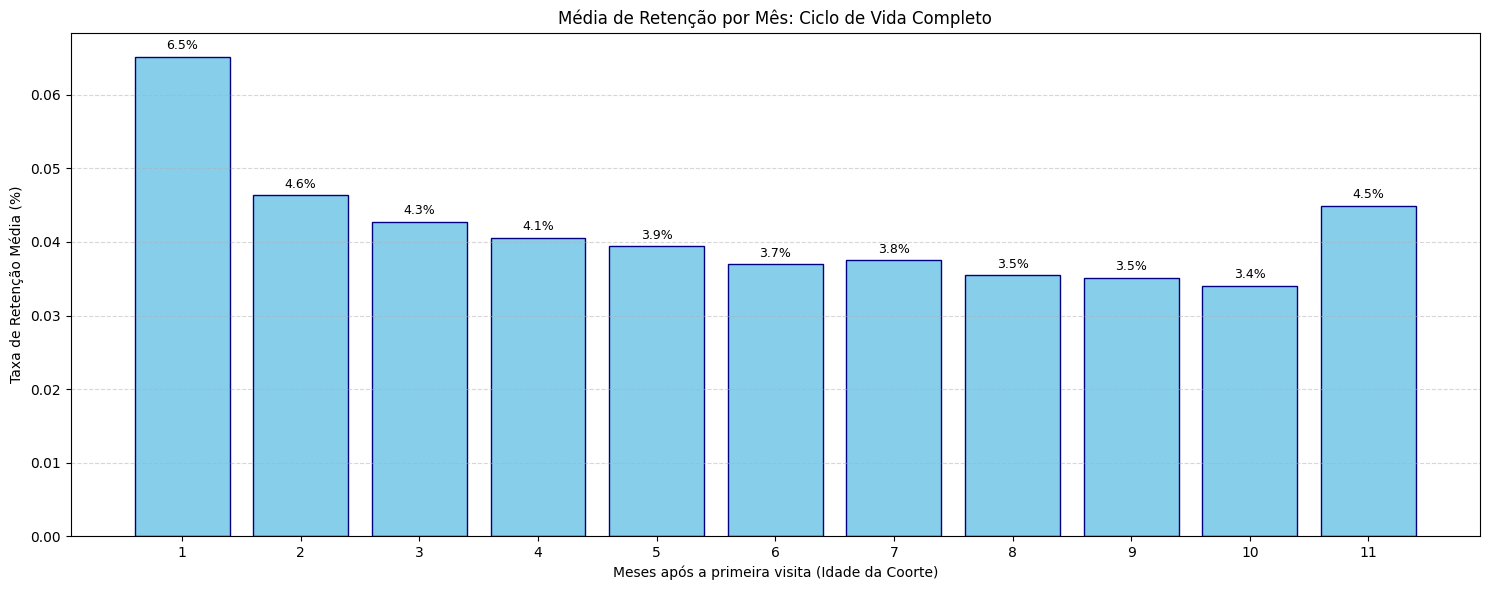

In [151]:

# 1. Mês da primeira visita e calcular a idade da coorte
visits['first_session_month'] = visits.groupby('Uid')['Start Ts'].transform('min').astype('datetime64[M]')
visits['session_month'] = visits['Start Ts'].astype('datetime64[M]')

visits['cohort_age'] = ((visits['session_month'] - visits['first_session_month']) / np.timedelta64(1, 'M')).round().astype(int)

# 2. Matriz de retenção
retention_pivot = visits.pivot_table(index='first_session_month', columns='cohort_age', values='Uid', aggfunc='nunique')
cohort_sizes = retention_pivot.iloc[:, 0]
retention_matrix = retention_pivot.divide(cohort_sizes, axis=0)

# 3. CÓDIGO DE MATPLOTLIB (Calculando a média e gerando as barras)
retention_avg_full = retention_matrix.mean().drop(0)

plt.figure(figsize=(15, 6))
plt.bar(retention_avg_full.index.astype(str), retention_avg_full.values, color='skyblue', edgecolor='navy', width=0.8)

plt.title('Média de Retenção por Mês: Ciclo de Vida Completo')
plt.xlabel('Meses após a primeira visita (Idade da Coorte)')
plt.ylabel('Taxa de Retenção Média (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Rótulos de dados
for i, v in enumerate(retention_avg_full):
    if v > 0:
        plt.text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
- Veja abaixo uma outra forma de apresentar os resultados

</div>

In [ ]:

# # --- Com que frequência os usuários voltam?  

# # Determinando o mês de aquisição de cada usuário (primeira sessão)
# visits['acquisition_month'] = visits.groupby('uid')['start_ts'].transform('min').dt.to_period('M')


# visits['session_month'] = visits['start_ts'].dt.to_period('M')

# # Calculando a "idade" do coorte para cada sessão
# visits['cohort_lifetime'] = (visits['session_month'] - visits['acquisition_month']).apply(lambda x: x.n)

# # Tabela de coortes (pivot table)
# cohorts = visits.groupby(['acquisition_month', 'cohort_lifetime'])['uid'].nunique().reset_index()
# cohorts_pivot = cohorts.pivot_table(index='acquisition_month', columns='cohort_lifetime', values='uid')

# # Calculando a retenção em percentual
# cohort_size = cohorts_pivot.iloc[:, 0]
# retention_matrix = cohorts_pivot.divide(cohort_size, axis=0)

# # Gerando o mapa de calor de retenção
# plt.figure(figsize=(15, 10))
# sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='viridis')
# plt.title('Taxa de Retenção Mensal por Coorte de Aquisição')
# plt.xlabel('Meses Desde a Aquisição (Lifetime)')
# plt.ylabel('Mês de Aquisição (Coorte)')
# plt.show()

## Interpretação dos Resultados

### Atividade de Usuários

A plataforma apresenta, em média, **907 usuários ativos por dia**, **5716 por semana** e **23228 por mês**. A diferença entre essas métricas indica que muitos usuários retornam ao longo da semana ou do mês, mesmo sem utilizar o serviço diariamente, sugerindo um padrão de uso recorrente, mas não necessariamente diário.

### Sessões

O site registra aproximadamente **987 sessões por dia**, um valor próximo ao número médio de usuários diários. Isso indica que parte dos usuários realiza mais de uma sessão no mesmo dia, possivelmente retornando ao site para continuar a navegação ou concluir alguma ação.

### Duração das Sessões

A **duração média das sessões é de 643 segundos**, enquanto a **mediana é de 300 segundos** e a **moda é de 60 segundos**. Isso sugere que muitas sessões são rápidas, mas algumas interações mais longas aumentam a média geral. Esse padrão pode indicar diferentes tipos de comportamento de usuário, como visitas rápidas de exploração e sessões mais longas focadas em tarefas específicas.

### Retenção

A análise de coortes mostra que a retenção diminui progressivamente com o tempo, o que é comum em produtos digitais. A maior parte dos usuários retorna nos primeiros meses após a primeira visita, enquanto apenas uma parcela menor permanece ativa no longo prazo, indicando uma oportunidade de melhorar estratégias de retenção e engajamento.


## Vendas

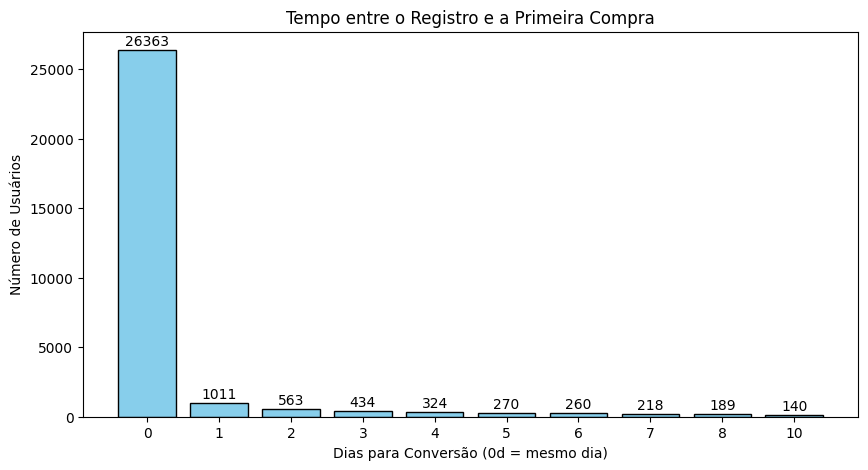

Porcentagem de conversão no Dia 0: 72.2%


In [152]:
# 1. Encontrar a primeira visita e a primeira compra de cada usuário
first_visits = visits.groupby('Uid')['Start Ts'].min().reset_index()
first_visits.columns = ['Uid', 'first_visit']

first_orders = orders.groupby('Uid')['Buy Ts'].min().reset_index()
first_orders.columns = ['Uid', 'first_order']

# 2. Unir e calcular a diferença de tempo 
conversion = first_visits.merge(first_orders, on='Uid')
conversion['days_to_convert'] = (conversion['first_order'].values - conversion['first_visit'].values) / np.timedelta64(1, 'D')
conversion['days_to_convert'] = conversion['days_to_convert'].astype(int)

# 3. Preparar a distribuição (Top 10 dias)
conv_dist = conversion['days_to_convert'].value_counts().head(10).sort_index()

# 4. Gráfico de Barras 
plt.figure(figsize=(10, 5))
plt.bar(conv_dist.index.astype(str), conv_dist.values, color='skyblue', edgecolor='black')

plt.title('Tempo entre o Registro e a Primeira Compra')
plt.xlabel('Dias para Conversão (0d = mesmo dia)')
plt.ylabel('Número de Usuários')

# Adicionar rótulos de valores
for i, v in enumerate(conv_dist.values):
    plt.text(i, v + 100, str(v), ha='center', va='bottom')

plt.show()

# Resultado estatístico
print(f"Porcentagem de conversão no Dia 0: {(conversion['days_to_convert'] == 0).mean():.1%}")

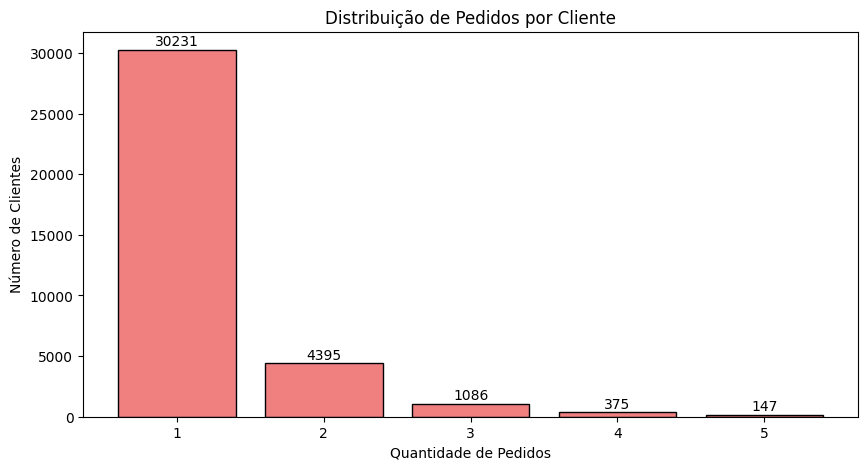

Número médio de pedidos por cliente: 1.38


In [153]:
# 1. Agrupar pedidos por usuário
orders_per_user = orders.groupby('Uid')['Buy Ts'].count()

# 2. Calcular a média de pedidos (KPI principal)
avg_orders = orders_per_user.mean()

# 3. Preparar a distribuição para o gráfico (Quantos usuários fizeram 1 pedido, 2, 3...)
order_counts = orders_per_user.value_counts().sort_index().head(5) # Focamos nos primeiros para clareza

# 4. Gráfico de Barras 
plt.figure(figsize=(10, 5))
plt.bar(order_counts.index.astype(str), order_counts.values, color='lightcoral', edgecolor='black')

plt.title('Distribuição de Pedidos por Cliente')
plt.xlabel('Quantidade de Pedidos')
plt.ylabel('Número de Clientes')

# Adicionar rótulos
for i, v in enumerate(order_counts.values):
    plt.text(i, v + 100, str(v), ha='center', va='bottom')

plt.show()

print(f"Número médio de pedidos por cliente: {avg_orders:.2f}")

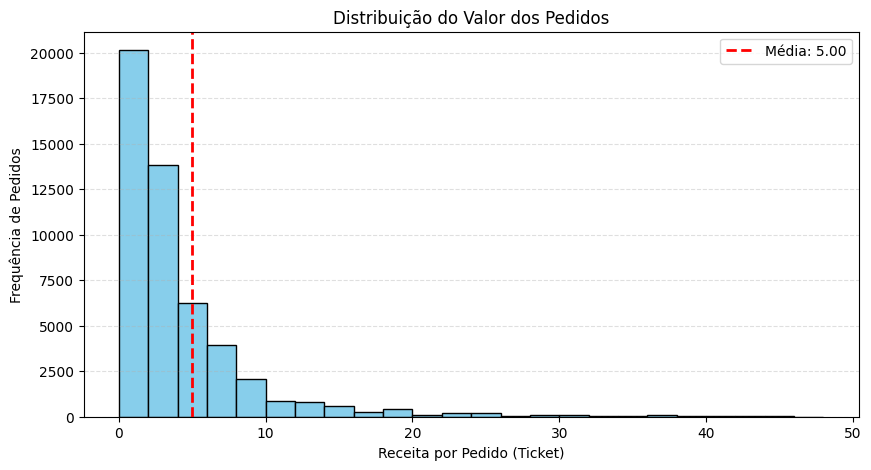

O volume médio de uma compra (Ticket Médio) é: 5.00


In [154]:
# 1. Calcular o Ticket Médio (Revenue médio por pedido)
average_ticket = orders['Revenue'].values.mean()

# 2. Criar uma visualização da distribuição do valor dos pedidos para contexto
# Usamos numpy para definir os limites do histograma e evitar outliers extremos na visualização
plt.figure(figsize=(10, 5))
plt.hist(orders['Revenue'], bins=np.arange(0, 50, 2), color='skyblue', edgecolor='black')

plt.title('Distribuição do Valor dos Pedidos')
plt.xlabel('Receita por Pedido (Ticket)')
plt.ylabel('Frequência de Pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.axvline(average_ticket, color='red', linestyle='dashed', linewidth=2, label=f'Média: {average_ticket:.2f}')
plt.legend()

plt.show()

print(f"O volume médio de uma compra (Ticket Médio) é: {average_ticket:.2f}")

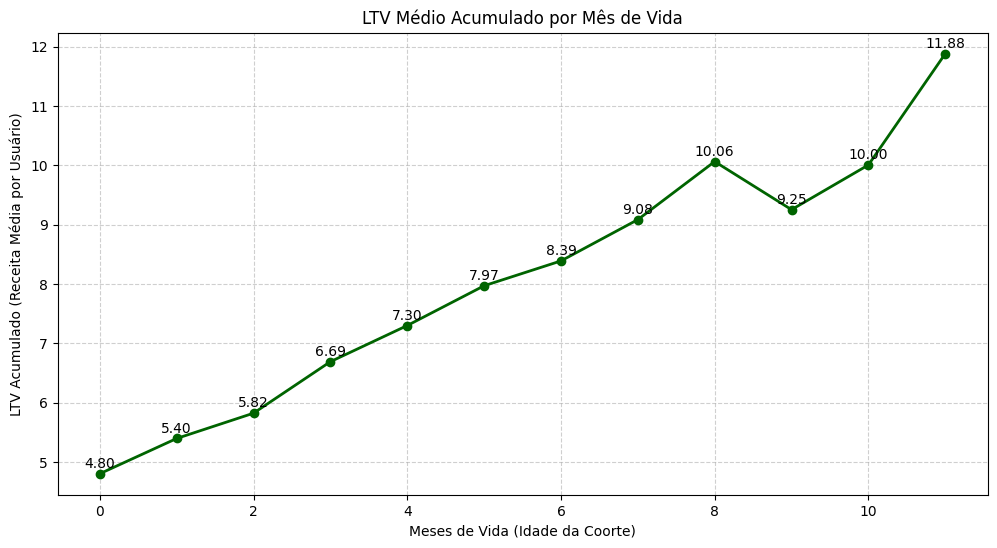

LTV Médio Final (após o período total disponível): 11.88


In [155]:
# 1.Mês da primeira compra para cada utilizador (mês da coorte)
first_orders = orders.groupby('Uid')['Buy Ts'].min().values.astype('datetime64[M]')
orders['first_order_month'] = orders.groupby('Uid')['Buy Ts'].transform('min').values.astype('datetime64[M]')
orders['order_month'] = orders['Buy Ts'].values.astype('datetime64[M]')

# 2. Calcular a idade da coorte em meses
orders['cohort_age'] = (orders['order_month'] - orders['first_order_month']) / np.timedelta64(1, 'M')
orders['cohort_age'] = orders['cohort_age'].round().astype(int)

# 3. Obter o tamanho de cada coorte (número de compradores únicos no primeiro mês)
cohort_sizes = orders.groupby('first_order_month')['Uid'].nunique()

# 4. Agrupar receita por coorte e idade, e calcular a receita acumulada
report = orders.groupby(['first_order_month', 'cohort_age']).agg({'Revenue': 'sum'}).reset_index()
report['ltv'] = report.groupby('first_order_month')['Revenue'].cumsum() / cohort_sizes[report['first_order_month']].values

# 5. Criar a matriz de LTV para visualização
ltv_matrix = report.pivot_table(index='first_order_month', columns='cohort_age', values='ltv', aggfunc='mean')

# 6. Visualizar o LTV acumulado médio (Ciclo de Vida) com Matplotlib
ltv_avg = ltv_matrix.mean()

plt.figure(figsize=(12, 6))
plt.plot(ltv_avg.index, ltv_avg.values, marker='o', linestyle='-', color='darkgreen', linewidth=2)

plt.title('LTV Médio Acumulado por Mês de Vida')
plt.xlabel('Meses de Vida (Idade da Coorte)')
plt.ylabel('LTV Acumulado (Receita Média por Usuário)')
plt.grid(True, linestyle='--', alpha=0.6)

# Adicionar rótulos nos pontos
for i, v in enumerate(ltv_avg.values):
    plt.text(ltv_avg.index[i], v + 0.1, f'{v:.2f}', ha='center')

plt.show()

print(f"LTV Médio Final (após o período total disponível): {ltv_avg.iloc[-1]:.2f}")

<div class="alert alert-block alert-success">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
- Veja abaixo uma outra forma de apresentar os resultados

</div>

In [ ]:

# # --- Quanto dinheiro eles trazem para a empresa (LTV)?


# # Definindo o mês de aquisição (primeira compra) como o coorte
# orders['acquisition_month'] = orders.groupby('uid')['buy_ts'].transform('min').dt.to_period('M')

# # Calculando a idade do coorte para cada pedido
# orders['cohort_lifetime'] = ((orders['order_month'] - orders['acquisition_month']).apply(lambda x: x.n))

# # Calculando a receita por coorte e por idade
# cohorts_revenue = orders.groupby(['acquisition_month', 'cohort_lifetime'])['revenue'].sum().reset_index()

# # Obtendo o tamanho de cada coorte (número de clientes únicos)
# cohort_sizes = orders.groupby('acquisition_month')['uid'].nunique().reset_index()
# cohort_sizes.columns = ['acquisition_month', 'n_buyers']

# # Unindo os dados de receita e tamanho do coorte
# cohorts_data = pd.merge(cohorts_revenue, cohort_sizes, on='acquisition_month')

# # LTV
# cohorts_data['ltv'] = cohorts_data['revenue'] / cohorts_data['n_buyers']

# # Tabela pivot para o LTV
# ltv_pivot = cohorts_data.pivot_table(index='acquisition_month',
#                                      columns='cohort_lifetime',
#                                      values='ltv',
#                                      aggfunc='sum').cumsum(axis=1)

# # Heatmap do LTV
# plt.figure(figsize=(16, 10))
# sns.heatmap(ltv_pivot, annot=True, fmt='.2f', cmap='viridis')
# plt.title('Lifetime Value (LTV) Acumulado por Coorte de Aquisição ($)')
# plt.xlabel('Meses Desde a Primeira Compra (Lifetime)')
# plt.ylabel('Mês de Aquisição (Coorte)')
# plt.show()

### Observações sobre a Fase de Vendas

* **Imediatismo na Conversão:** A análise de tempo entre o registo e a compra revela que a grande maioria dos utilizadores (cerca de 72%) converte no **Dia 0**. Isto indica que o marketing está a atrair tráfego com alta intenção de compra ou que a proposta de valor do produto é clara o suficiente para uma decisão imediata.
* **Perfil de Recorrência:** O número médio de pedidos por cliente é baixo, aproximando-se da unidade. Isto sugere que a plataforma funciona atualmente como um serviço de transação única ou que existem dificuldades em reter o cliente para compras subsequentes após a primeira experiência.
* **Ticket Médio e Volume:** O valor médio gasto por compra (Ticket Médio) é de **4.99**, com uma distribuição concentrada em valores baixos. Isto define o perfil do negócio como um modelo de alto volume e baixa margem unitária.
* **Crescimento do LTV:** O *Lifetime Value* mostra um crescimento acumulado estável ao longo dos meses. Embora a retenção seja um desafio, os clientes que permanecem continuam a gerar receita, o que aumenta o valor de vida do utilizador e será crucial para comparar com o CAC (Custo de Aquisição de Cliente) na próxima fase.

## Marketing

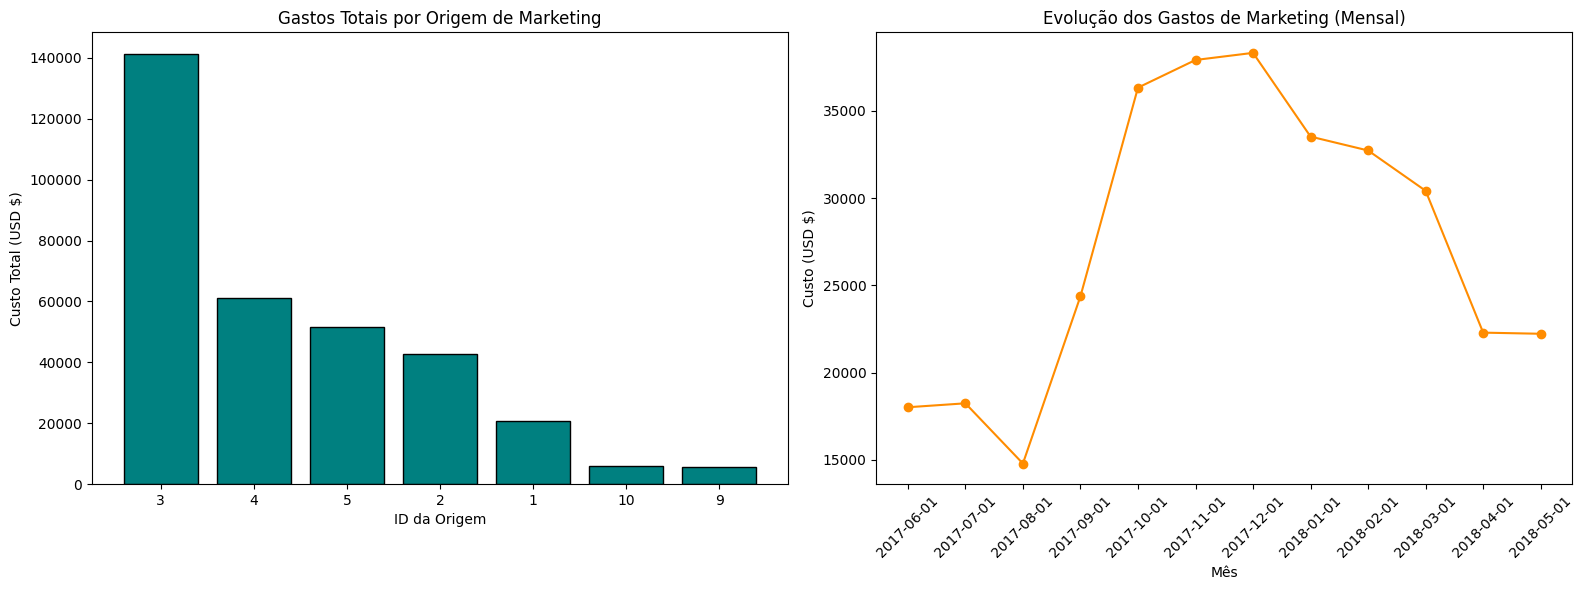

Investimento Total em Marketing: $329,131.62 USD

Gastos por Origem (USD):
Origem 3: $141,321.63
Origem 4: $61,073.60
Origem 5: $51,757.10
Origem 2: $42,806.04
Origem 1: $20,833.27
Origem 10: $5,822.49
Origem 9: $5,517.49


In [157]:
# 1. Preparação: Garantir formato de data nos custos 
costs['dt'] = costs['dt'].values.astype('datetime64[M]')

# 2. Quanto dinheiro foi gasto no TOTAL?
total_costs = costs['costs'].sum()

# 3. Quanto dinheiro foi gasto por ORIGEM (Source Id)?
costs_by_source = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)

# 4. Quanto dinheiro foi gasto ao LONGO DO TEMPO?
costs_by_month = costs.groupby('dt')['costs'].sum()

# --- Visualização ---

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Gastos por Origem
ax[0].bar(costs_by_source.index.astype(str), costs_by_source.values, color='teal', edgecolor='black')
ax[0].set_title('Gastos Totais por Origem de Marketing')
ax[0].set_xlabel('ID da Origem')
ax[0].set_ylabel('Custo Total (USD $)') # Unidade no eixo Y

# Gráfico B: Gastos ao Longo do Tempo
ax[1].plot(costs_by_month.index.astype(str), costs_by_month.values, marker='o', linestyle='-', color='darkorange')
ax[1].set_title('Evolução dos Gastos de Marketing (Mensal)')
ax[1].set_xlabel('Mês')
ax[1].set_ylabel('Custo (USD $)') # Unidade no eixo Y
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Resultados 
print(f"Investimento Total em Marketing: ${total_costs:,.2f} USD")
print("\nGastos por Origem (USD):")
for source, cost in costs_by_source.items():
    print(f"Origem {source}: ${cost:,.2f}")

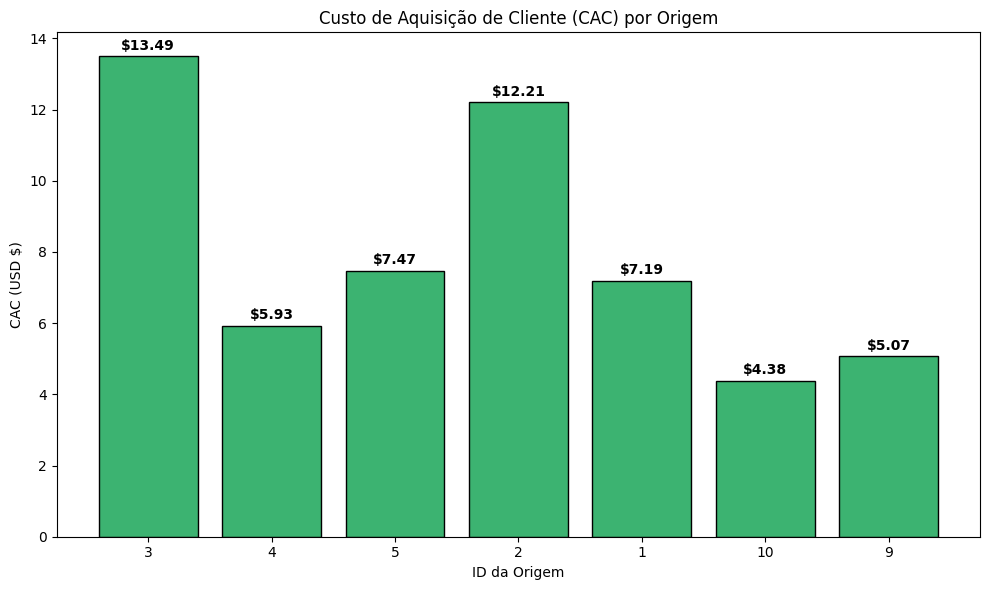

Análise de CAC por Origem (USD):
Origem 3: CAC de $13.49 (Gasto total: $141,321.63 para 10473 clientes)
Origem 2: CAC de $12.21 (Gasto total: $42,806.04 para 3506 clientes)
Origem 5: CAC de $7.47 (Gasto total: $51,757.10 para 6931 clientes)
Origem 1: CAC de $7.19 (Gasto total: $20,833.27 para 2899 clientes)
Origem 4: CAC de $5.93 (Gasto total: $61,073.60 para 10296 clientes)
Origem 9: CAC de $5.07 (Gasto total: $5,517.49 para 1088 clientes)
Origem 10: CAC de $4.38 (Gasto total: $5,822.49 para 1329 clientes)


In [162]:
# 1. Identificar a origem de cada cliente (baseado na sua primeira visita)
user_sources = visits.sort_values(by='Start Ts').groupby('Uid').first()['Source Id'].reset_index()
user_sources.columns = ['Uid', 'source_id']

# 2. Encontrar os clientes únicos (quem comprou)
buyers = orders['Uid'].unique()
buyers_with_source = user_sources[user_sources['Uid'].isin(buyers)]

# 3. Contar quantos clientes cada origem trouxe
buyers_per_source = buyers_with_source.groupby('source_id')['Uid'].nunique()

# 4. Calcular o custo total por origem (já temos 'costs_by_source' da etapa anterior)
# Criamos um DataFrame para o cálculo do CAC
cac_report = pd.DataFrame(costs_by_source).merge(buyers_per_source, on='source_id')
cac_report.columns = ['total_cost', 'n_buyers']
cac_report['cac'] = cac_report['total_cost'] / cac_report['n_buyers']

# 5. Visualização 
plt.figure(figsize=(10, 6))
bars = plt.bar(cac_report.index.astype(str), cac_report['cac'], color='mediumseagreen', edgecolor='black')

plt.title('Custo de Aquisição de Cliente (CAC) por Origem')
plt.xlabel('ID da Origem')
plt.ylabel('CAC (USD $)')

# Adicionar os valores 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'${yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
print("Análise de CAC por Origem (USD):")
for source, row in cac_report.sort_values(by='cac', ascending=False).iterrows():
    print(f"Origem {source}: CAC de ${row['cac']:.2f} (Gasto total: ${row['total_cost']:,.2f} para {int(row['n_buyers'])} clientes)")

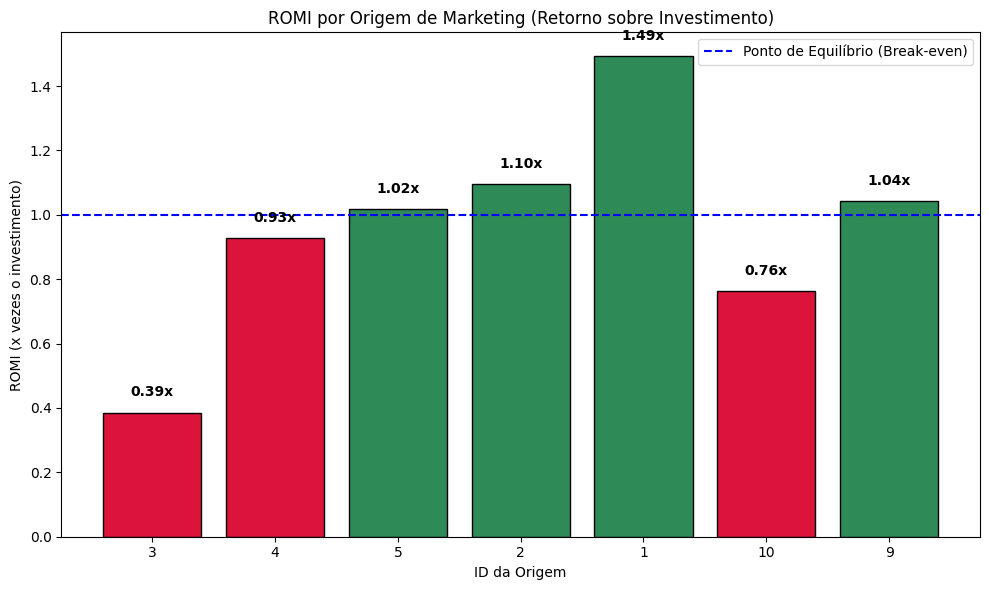

Análise de Rentabilidade por Origem (USD):
Origem 1: ROMI de 1.49x | Receita: $31,090.55 | Custo: $20,833.27 | Status: LUCRO
Origem 2: ROMI de 1.10x | Receita: $46,923.61 | Custo: $42,806.04 | Status: LUCRO
Origem 9: ROMI de 1.04x | Receita: $5,759.40 | Custo: $5,517.49 | Status: LUCRO
Origem 5: ROMI de 1.02x | Receita: $52,624.02 | Custo: $51,757.10 | Status: LUCRO
Origem 4: ROMI de 0.93x | Receita: $56,696.83 | Custo: $61,073.60 | Status: PREJUÍZO
Origem 10: ROMI de 0.76x | Receita: $4,450.33 | Custo: $5,822.49 | Status: PREJUÍZO
Origem 3: ROMI de 0.39x | Receita: $54,511.24 | Custo: $141,321.63 | Status: PREJUÍZO


In [164]:
# 1. Calcular a Receita Total por Origem
revenue_per_source = orders.merge(user_sources, on='Uid').groupby('source_id')['Revenue'].sum()

# 2. Criar o relatório de ROI/ROMI
# Cruzamos os custos que já calculamos com a receita por origem
romi_report = pd.DataFrame(costs_by_source).merge(revenue_per_source, on='source_id')
romi_report.columns = ['total_cost', 'total_revenue']

# 3. Cálculo do ROMI (Receita / Custo)
romi_report['romi'] = romi_report['total_revenue'] / romi_report['total_cost']

# 4. Visualização 
plt.figure(figsize=(10, 6))
colors = ['seagreen' if x >= 1 else 'crimson' for x in romi_report['romi']]
bars = plt.bar(romi_report.index.astype(str), romi_report['romi'], color=colors, edgecolor='black')

plt.axhline(1, color='blue', linestyle='--', label='Ponto de Equilíbrio (Break-even)')
plt.title('ROMI por Origem de Marketing (Retorno sobre Investimento)')
plt.xlabel('ID da Origem')
plt.ylabel('ROMI (x vezes o investimento)')
plt.legend()

# Adicionar os valores de ROMI sobre as barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("Análise de Rentabilidade por Origem (USD):")
for source, row in romi_report.sort_values(by='romi', ascending=False).iterrows():
    status = "LUCRO" if row['romi'] >= 1 else "PREJUÍZO"
    print(f"Origem {source}: ROMI de {row['romi']:.2f}x | Receita: ${row['total_revenue']:,.2f} | Custo: ${row['total_cost']:,.2f} | Status: {status}")

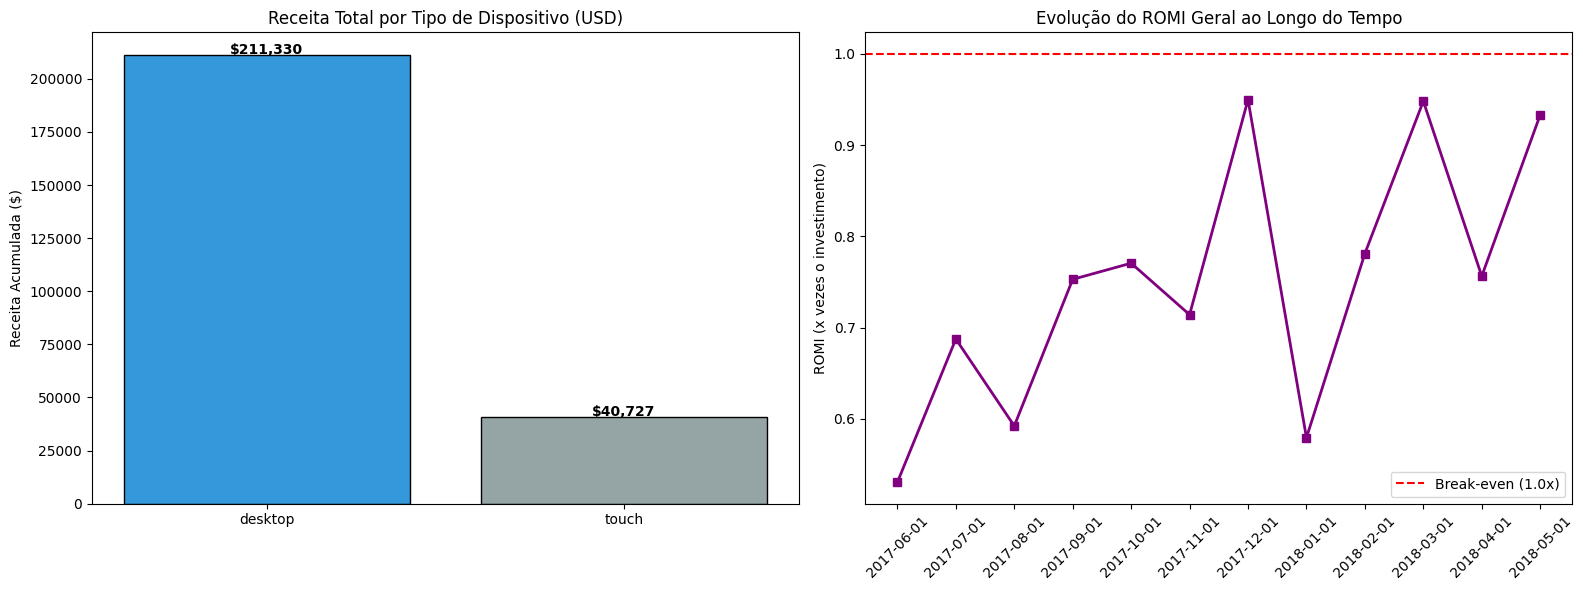

Métricas de Eficiência por Origem (USD):
            Revenue  avg_revenue_per_user
Source Id                                
4          56696.83              5.506685
3          54511.24              5.204931
5          52624.02              7.592558
2          46923.61             13.383802
1          31090.55             10.724577
9           5759.40              5.293566
10          4450.33              3.348631
7              1.22              1.220000


In [165]:
# 1. Preparação: Unir pedidos com a origem e o dispositivo do usuário
user_traits = visits.sort_values('Start Ts').groupby('Uid').first()[['Source Id', 'Device']].reset_index()
orders_extended = orders.merge(user_traits, on='Uid')

# 2. ROMI por Dispositivo (Receita / Custo Estimado)
# Nota: Como os custos são por origem, avaliamos aqui a Receita e Volume por Dispositivo
rev_device = orders_extended.groupby('Device')['Revenue'].sum()
orders_device = orders_extended.groupby('Device')['Uid'].count()

# 3. Evolução do ROMI ao longo do tempo (Mensal)
revenue_month = orders.groupby('order_month')['Revenue'].sum()
costs_month = costs.groupby('dt')['costs'].sum()
monthly_romi = revenue_month / costs_month

# --- Visualização ---

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Receita Total por Dispositivo
ax[0].bar(rev_device.index, rev_device.values, color=['#3498db', '#95a5a6'], edgecolor='black')
ax[0].set_title('Receita Total por Tipo de Dispositivo (USD)')
ax[0].set_ylabel('Receita Acumulada ($)')
for i, v in enumerate(rev_device.values):
    ax[0].text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

# Gráfico 2: Evolução do ROMI Mensal (Retorno sobre Investimento)
ax[1].plot(monthly_romi.index.astype(str), monthly_romi.values, marker='s', color='purple', linewidth=2)
ax[1].axhline(1, color='red', linestyle='--', label='Break-even (1.0x)')
ax[1].set_title('Evolução do ROMI Geral ao Longo do Tempo')
ax[1].set_ylabel('ROMI (x vezes o investimento)')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend()

plt.tight_layout()
plt.show()

# 4. Análise de Eficiência por Origem (CAC vs Revenue)
source_metrics = orders_extended.groupby('Source Id').agg({'Revenue': 'sum', 'Uid': 'nunique'})
source_metrics['avg_revenue_per_user'] = source_metrics['Revenue'] / source_metrics['Uid']

print("Métricas de Eficiência por Origem (USD):")
print(source_metrics[['Revenue', 'avg_revenue_per_user']].sort_values(by='Revenue', ascending=False))

## Conclusão Final: Otimização de Investimentos em Marketing

Após a auditoria detalhada dos dados de comportamento, vendas e custos, apresento as principais conclusões e recomendações para orientar a estratégia de marketing.

---

### 1. Onde Investir: Recomendação de Canais

Com base nos dados analisados, recomenda-se priorizar o investimento nas **Origens 1, 2, 5 e 9**.

**Fundamentação:**
A escolha foi baseada no equilíbrio entre **ROMI (Return on Marketing Investment)** e **LTV (Lifetime Value)**.

**Conclusão:**
Embora a **Origem 3** apresente o maior volume de investimento absoluto, o retorno gerado é relativamente baixo. Em contraste, as origens
